# Short-Time Narrow-Banded Mode Decomposition (STNBMD)

> McNeill, S.I. (2016). *Decomposing a signal into short-time narrow-banded modes.*  
> Journal of Sound and Vibration, 373:325–339.  
> https://doi.org/10.1016/j.jsv.2016.03.015

STNBMD decomposes a **single-channel** real signal into a sum of **AM–FM analytic sinusoids** whose amplitude and instantaneous frequency vary **slowly** (short-time narrow-banded modes). The author presents it as a **time-domain extension of VMD** that can track **time-varying / crossing frequencies** (e.g. order tracking without a tachometer).

This notebook summarises the variational principle and reproduces the MATLAB demo `example/test_ord_trk_stnbmd.m` with `pysdkit.STNBMD`.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import STNBMD
from pysdkit._vncmd.stnbmd import (
    make_order_tracking_demo,
    fft_two_to_one,
)

plt.rcParams["figure.dpi"] = 120
print(STNBMD())

Short-Time Narrow-Banded Mode Decomposition (STNBMD)


## 2. Algorithm principles (paper)

### 2.1 Analytic AM–FM modes

From the real measurement $x(t)$, form the analytic signal via a Hilbert / 90° phase shift:

$$
\tilde{x}(t)=x(t)+i\,\mathcal{H}\{x\}(t)=\sum_{k=1}^{K} a_k(t)\,e^{i\psi_k(t)}.
$$

Each mode is a **short-time narrow-banded** sinusoid: $a_k(t)$ and $\omega_k(t)=\dot\psi_k(t)$ vary slowly.

### 2.2 Variational criteria

STNBMD minimises an objective that balances three requirements:

1. **smooth instantaneous amplitude** (penalise $\|D^{(1)} a_k\|$);
2. **smooth instantaneous frequency / phase** (penalise $\|D^{(2)} \psi_k\|$);
3. **complete reconstruction** of the analytic data.

A minimum is approached by **suboptimal alternating updates** of amplitude and phase (efficient linear smoothing filters), not by a single convex ADMM solve as in classical VMD.

### 2.3 Update intuition (MATLAB `stnbm_decomp_ig`)

For mode $k$, with residual $\tilde{x}-\sum_{j\neq k}\tilde{x}_j$:

1. **Amplitude update**: demodulate residual by $e^{-i\psi_k}$ and apply amplitude smoother $F_1(\alpha)=(\alpha Q_1+I)^{-1}$;
2. **Phase update**: form $a_k e^{i\psi_k}$, take `unwrap(angle(·))`, apply phase smoother $F_2(\beta)=(\beta Q_2+I)^{-1}$;
3. Schedule $(\alpha,\beta)$ over iterations (`abitr`) from coarse to fine.

Compared with VMD: STNBMD works in the **analytic time domain** and explicitly tracks **time-varying IF**, so crossing / sweeping orders are admissible.

## 3. MATLAB order-tracking demo

Synthetic mixture of three **upsweep harmonics** with slowly modulated amplitudes (`test_ord_trk_stnbmd.m`). Initial guess: unit-amplitude tones at 2, 4, 6 Hz.

In [2]:
demo = make_order_tracking_demo(fs=100.0, nt=1000)
t = demo["t"]
fs = float(demo["fs"])
xe = demo["signal"]
xc = demo["modes"]
fp = demo["true_if"]

model = STNBMD(
    fs=fs,
    alpha=[1.0e-1, 1.0e-2, 1.0e-2],
    beta=[1.0, 1.0e-1, 1.0e-3],
    abitr=[20, 50, 200],
    tol=1e-6,
)
modes, xnb, err, amp, phz = model.fit_transform(
    xe, frequencies=[2.0, 4.0, 6.0], return_all=True
)
xs = np.real(xnb)  # (nt, K) as in MATLAB
xsr = np.sum(xs, axis=1)
ifrq = model.instantaneous_frequency_hz()
tfrq = 0.5 * (t[:-1] + t[1:])

rel = np.linalg.norm(xsr - xe) / np.linalg.norm(xe)
print(f"modes shape (K, nt) = {modes.shape}")
print(f"iterations = {err.size}, final err = {err[-1]:.3e}")
print(f"relative reconstruction error = {rel:.3e}")

modes shape (K, nt) = (3, 1000)
iterations = 128, final err = 6.547e-07
relative reconstruction error = 1.322e-02


### 3.1 Convergence

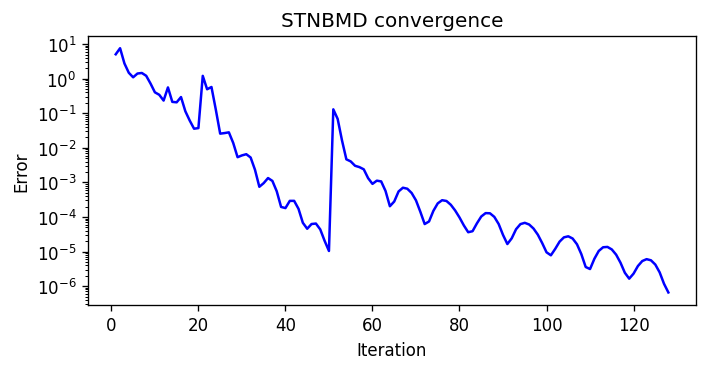

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.semilogy(np.arange(1, err.size + 1), err, "b")
ax.set_xlabel("Iteration")
ax.set_ylabel("Error")
ax.set_title("STNBMD convergence")
plt.tight_layout()
plt.show()

### 3.2 Mixture reconstruction (MATLAB Fig. 5 style)

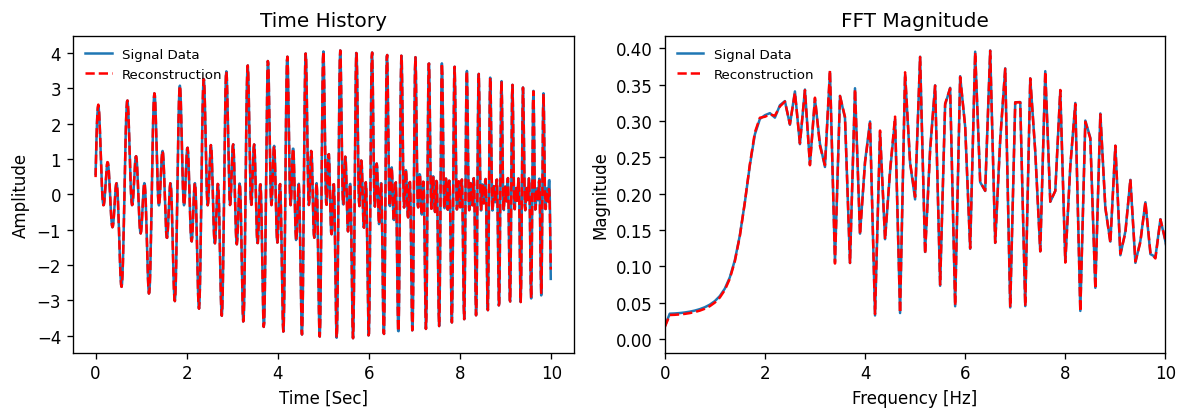

In [4]:
xsrf1, f1 = fft_two_to_one(np.fft.fft(xsr), fs, nt=xe.size)
xef1, _ = fft_two_to_one(np.fft.fft(xe), fs, nt=xe.size)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(t, xe, label="Signal Data")
axes[0].plot(t, xsr, "--r", label="Reconstruction")
axes[0].set_xlabel("Time [Sec]")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Time History")
axes[0].legend(fontsize=8, frameon=False)

axes[1].plot(f1, np.abs(xef1), label="Signal Data")
axes[1].plot(f1, np.abs(xsrf1), "--r", label="Reconstruction")
axes[1].set_xlim(0, 10)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Magnitude")
axes[1].set_title("FFT Magnitude")
axes[1].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

### 3.3 Per-mode waveforms, spectra and IF (MATLAB Fig. 6 style)

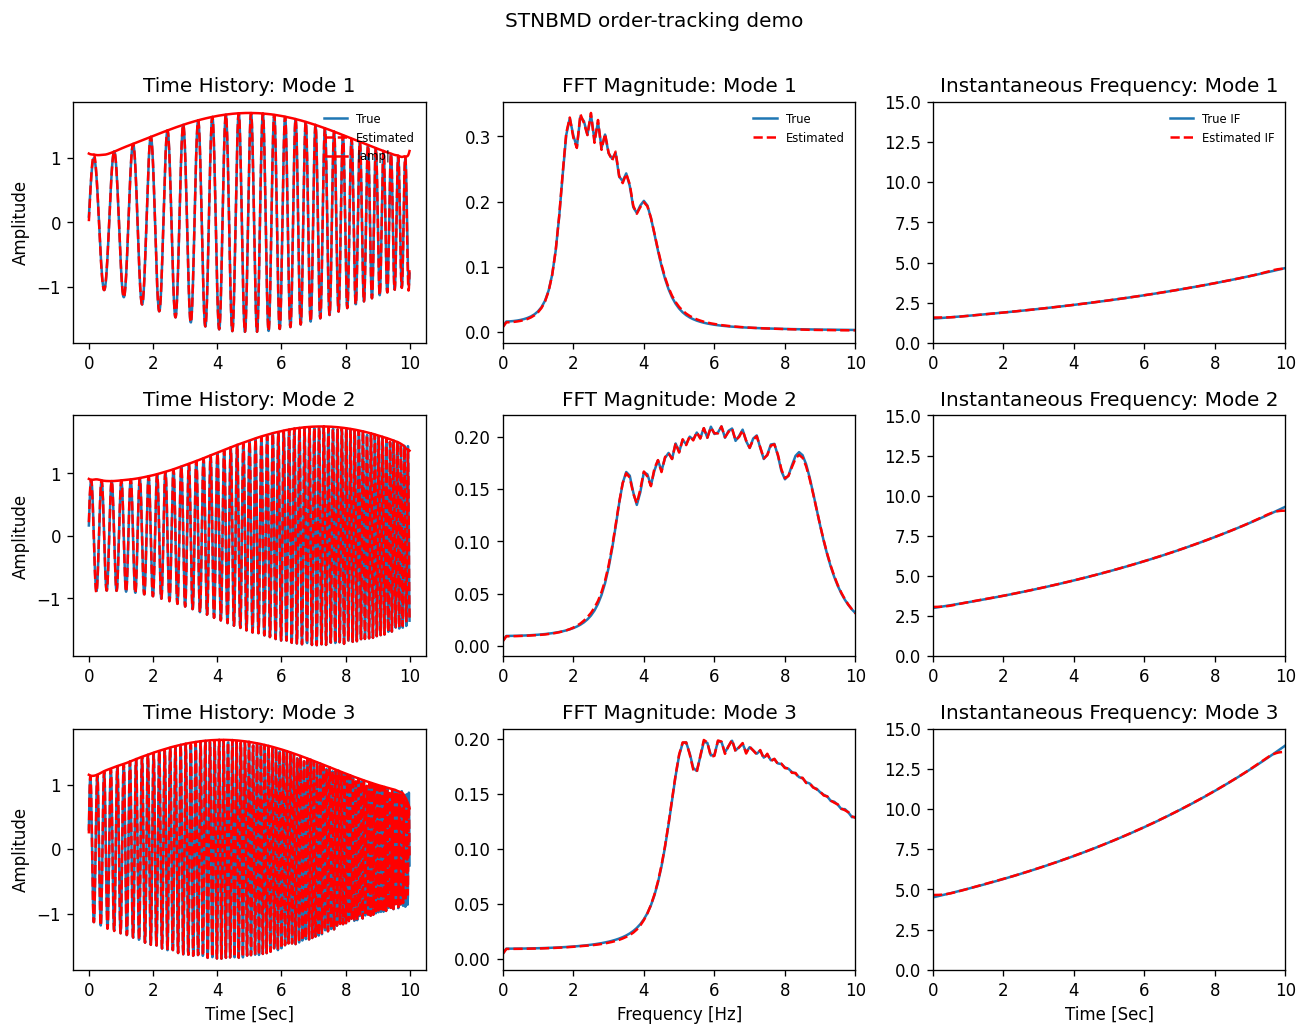

In [5]:
xsf1, f1 = fft_two_to_one(np.fft.fft(xs, axis=0), fs, nt=xe.size)
xcf1, _ = fft_two_to_one(np.fft.fft(xc, axis=0), fs, nt=xe.size)

fig, axes = plt.subplots(3, 3, figsize=(11, 8.5))
for k in range(3):
    axes[k, 0].plot(t, xc[:, k], label="True")
    axes[k, 0].plot(t, xs[:, k], "--r", label="Estimated")
    axes[k, 0].plot(t, np.abs(amp[:, k]), "-r", lw=1.5, label="|amp|")
    axes[k, 0].set_ylabel("Amplitude")
    axes[k, 0].set_title(f"Time History: Mode {k + 1}")
    if k == 0:
        axes[k, 0].legend(fontsize=7, frameon=False, loc="upper right")

    axes[k, 1].plot(f1, np.abs(xcf1[:, k]), label="True")
    axes[k, 1].plot(f1, np.abs(xsf1[:, k]), "--r", label="Estimated")
    axes[k, 1].set_xlim(0, 10)
    axes[k, 1].set_title(f"FFT Magnitude: Mode {k + 1}")
    if k == 0:
        axes[k, 1].legend(fontsize=7, frameon=False, loc="upper right")

    axes[k, 2].plot(t, fp[:, k], label="True IF")
    axes[k, 2].plot(tfrq, ifrq[:, k], "--r", label="Estimated IF")
    axes[k, 2].set_xlim(0, 10)
    axes[k, 2].set_ylim(0, 15)
    axes[k, 2].set_title(f"Instantaneous Frequency: Mode {k + 1}")
    if k == 0:
        axes[k, 2].legend(fontsize=7, frameon=False, loc="upper right")

axes[2, 0].set_xlabel("Time [Sec]")
axes[2, 1].set_xlabel("Frequency [Hz]")
axes[2, 2].set_xlabel("Time [Sec]")
fig.suptitle("STNBMD order-tracking demo", y=1.01)
plt.tight_layout()
plt.show()

## 4. Takeaways

- STNBMD targets **slowly AM–FM / short-time narrow-band** modes with **joint IF tracking**.
- It is **not** classical VMD (constant centre frequencies in the Fourier domain), but a **related variational time-domain** method suited to sweeping / crossing orders.
- PySDKit API: `STNBMD.fit_transform(..., frequencies=[...])` or explicit `ampg` / `phzg` initialisation; `return_all=True` exposes analytic modes, convergence history, complex amplitude and phase.